# Pharma Adherence Package Tutorial

This notebook demonstrates how to use the `pharma_adherence` package to clean prescription data, summarize patient adherence, visualize adherence patterns, and evaluate which features are most predictive of patient adherence.

The main research question for this tutorial is:

**Which features are most predictive of patient adherence?**

To answer this, we compare several logistic regression models using different feature sets. The outcome variable is `adherence_flag`, where `1` means the patient is classified as adherent and `0` means the patient is not adherent.


## 1. Import the package and supporting libraries

The package contains classes and functions for loading data, cleaning prescription records, generating visualizations, creating patient profiles, and training machine learning models.


In [14]:
import pandas as pd
import matplotlib.pyplot as plt

from src.pharma_adherence.data import PharmaDataset
from src.pharma_adherence.modeling import ModelTrainer


## 2. Load the raw prescription dataset

The `PharmaDataset` class loads the raw CSV file into a pandas DataFrame. This lets us use package methods for cleaning, visualization, saving, and patient-level summaries.


In [15]:
dataset = PharmaDataset("data/raw/prescriptions_large_raw.csv")
dataset.df.head()


,patient_id,fill_date,drug_name,days_supply,quantity_dispensed,refill_number,patient_age,sex,zip_code,prescriber_id,pharmacy_name,copay_amount,adherence_flag,proportion_days_covered
0,P001,2024-12-30,amoxicillin,60,60,0.0,34,f,94720.0,D123,walgreens pharmacy,19.73,0,0.51
1,P001,Jan 26 2025,PANTOPRAZOLE,60,120,NaN,34,f,94720.0,D208,csv pharmacy,9,0,0.70
2,P001,Mar 02 2025,AMLODIPINE 5MG,30days,30,NaN,34,f,94720.0,D217,Walgreens,12.6,0,0.63
3,P001,2025-04-04,Metformin HCl,90 days,90,3.0,34,f,94720.0,D159,CSV #13239,$16.55,0,0.63
4,P002,12/30/2024,Albuterol 180mcg,90 days,30,NaN,40,F,90210.0,D197,Walgreens #83887,17.18,0,0.62


## 3. Clean the dataset

The `.clean()` method standardizes column names, cleans dates and numeric variables, normalizes text columns such as drug and pharmacy names, removes invalid values, drops duplicate rows, and removes records missing critical fields such as patient ID, fill date, or drug name.


In [16]:
dataset.clean()
dataset.df.head()


c:\Users\andre\OneDrive\Documents\CDD209\cdd209-final-template\src\pharma_adherence\cleaning.py:140: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["adherence_flag"] = adherence_text.replace({


,patient_id,fill_date,drug_name,days_supply,quantity_dispensed,refill_number,patient_age,sex,zip_code,prescriber_id,pharmacy_name,copay_amount,adherence_flag,proportion_days_covered
0,P001,2024-12-30,amoxicillin,60.0,60.0,0.0,34.0,female,94720.0,D123,walgreens,19.73,0.0,0.51
1,P001,2025-01-26,pantoprazole,60.0,120.0,NaN,34.0,female,94720.0,D208,cvs,9.00,0.0,0.70
2,P001,2025-03-02,amlodipine,30.0,30.0,NaN,34.0,female,94720.0,D217,walgreens,12.60,0.0,0.63
3,P001,2025-04-04,metformin,90.0,90.0,3.0,34.0,female,94720.0,D159,cvs,16.55,0.0,0.63
4,P002,2024-12-30,albuterol,90.0,30.0,NaN,40.0,female,90210.0,D197,walgreens,17.18,0.0,0.62


Save the cleaned dataset so the processed version can be reused later.


In [17]:
dataset.save("data/processed/prescriptions_large_cleaned.csv")


## 4. Explore the cleaned data

Before modeling, it is important to inspect the cleaned dataset and understand the distribution of key adherence-related variables.


In [18]:
dataset.df.describe(include="all")


,patient_id,fill_date,drug_name,days_supply,quantity_dispensed,refill_number,patient_age,sex,zip_code,prescriber_id,pharmacy_name,copay_amount,adherence_flag,proportion_days_covered
count,1796,1796,1796,1796.00000,1796.000000,622.000000,1796.000000,1796,1329,1796,1796,1796.000000,1796.000000,1796.000000
unique,500,NaN,9,NaN,NaN,NaN,NaN,2,6,201,2,NaN,NaN,NaN
top,P029,NaN,pantoprazole,NaN,NaN,NaN,NaN,female,94110.0,D183,walgreens,NaN,NaN,NaN
freq,5,NaN,218,NaN,NaN,NaN,NaN,915,253,19,938,NaN,NaN,NaN
mean,NaN,2025-02-14 06:34:28.596881920,NaN,76.36971,74.097996,1.474277,52.909243,NaN,NaN,NaN,NaN,14.697389,0.240535,0.661047
min,NaN,2024-12-27 00:00:00,NaN,30.00000,30.000000,0.000000,20.000000,NaN,NaN,NaN,NaN,5.000000,0.000000,0.340000
25%,NaN,2025-01-05 00:00:00,NaN,60.00000,30.000000,0.000000,36.000000,NaN,NaN,NaN,NaN,9.382500,0.000000,0.570000
50%,NaN,2025-02-03 00:00:00,NaN,90.00000,60.000000,1.000000,53.000000,NaN,NaN,NaN,NaN,14.655000,0.000000,0.660000
75%,NaN,2025-03-06 00:00:00,NaN,120.00000,90.000000,2.000000,70.000000,NaN,NaN,NaN,NaN,20.000000,0.000000,0.750000
max,NaN,2025-05-06 00:00:00,NaN,120.00000,120.000000,4.000000,85.000000,NaN,NaN,NaN,NaN,24.990000,1.000000,1.000000


### Distribution of drug names

This plot shows how frequently different drugs appear in the dataset.


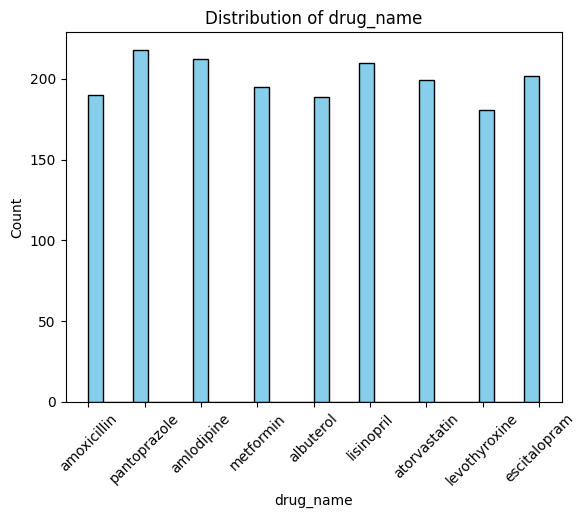

In [19]:
dataset.hist("drug_name").show()

### Average proportion of days covered by drug name

This plot compares average adherence across medication groups. Some drugs may be associated with higher or lower adherence because of side effects, dosing burden, cost, or whether the medication is used for chronic versus short-term treatment.


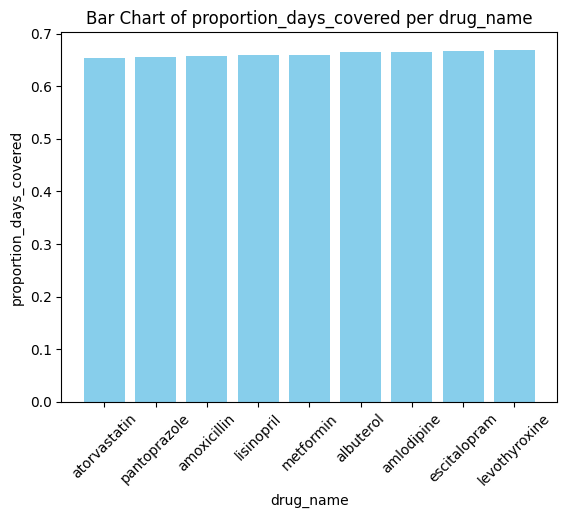

In [20]:
dataset.bar("drug_name", "proportion_days_covered").show()

### Patient age versus proportion of days covered

This scatter plot checks whether older or younger patients appear to have different adherence patterns.


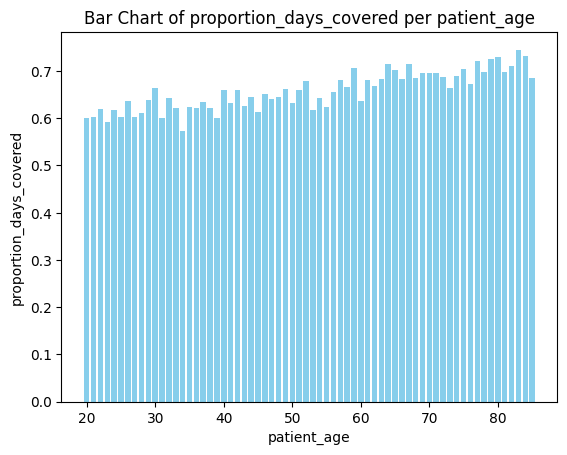

In [21]:
dataset.scatter("patient_age", "proportion_days_covered").show()


## 5. Generate a patient adherence summary

The package can summarize an individual patient's prescription history. For example, patient `P057` is summarized below.


In [22]:
patient = dataset.get_patient("P057")
patient.summary()


{'patient_id': 'P057',
 'total_fills': 1796,
 'avg_copay': np.float64(14.697388641425391),
 'avg_days_supply': np.float64(76.36971046770601),
 'pdc': np.float64(0.6610467706013362),
 'adherent': np.False_}

The patient summary includes total fills, average copay, average days supply, average proportion of days covered, and whether the patient meets the adherence threshold.


## 6. Compare feature sets for predicting adherence

To determine which features are most predictive of patient adherence, we train several logistic regression models using different feature sets. The target variable is `adherence_flag`.

The feature sets below are designed to test different clinically meaningful groups of predictors:

1. **Cost only:** `copay_amount`
2. **Demographics only:** `patient_age`, `sex`
3. **Medication burden only:** `days_supply`, `quantity_dispensed`, `refill_number`
4. **Medication identity only:** `drug_name`, `pharmacy_name`
5. **Cost + demographics:** `copay_amount`, `patient_age`, `sex`
6. **All available features:** combines cost, demographics, medication burden, medication identity, and prescriber/location information

We compare model performance using accuracy, precision, recall, and ROC-AUC. ROC-AUC is especially useful because it measures how well the model separates adherent from non-adherent patients across thresholds.


In [23]:
import time
import pandas as pd

try:
    from tqdm.notebook import tqdm
except ImportError:
    tqdm = None


feature_sets = {
    "cost_only": ["copay_amount"],

    "demographics_only": ["patient_age", "sex"],

    "medication_burden_only": [
        "days_supply",
        "quantity_dispensed",
        "refill_number"
    ],

    "medication_identity_only": [
        "drug_name",
        "pharmacy_name"
    ],

    "cost_plus_demographics": [
        "copay_amount",
        "patient_age",
        "sex"
    ],

    "cost_plus_medication_burden": [
        "copay_amount",
        "days_supply",
        "quantity_dispensed",
        "refill_number"
    ],

    "core_features": [
        "copay_amount",
        "patient_age",
        "sex",
        "days_supply",
        "quantity_dispensed",
        "refill_number",
        "drug_name",
        "pharmacy_name"
    ],
}

results = []

iterator = feature_sets.items()
if tqdm is not None:
    iterator = tqdm(iterator, total=len(feature_sets), desc="Training feature-set models")

for name, features in iterator:
    start_time = time.time()
    print(f"\nStarting model: {name}")
    print(f"Features: {features}")

    try:
        # Keep only the selected features and target.
        model_df = dataset.df[features + ["adherence_flag"]].copy()

        # Remove rows missing the target.
        model_df = model_df.dropna(subset=["adherence_flag"])

        # Make sure target is numeric binary.
        model_df["adherence_flag"] = model_df["adherence_flag"].astype(int)

        # Train logistic regression using your package's ModelTrainer.
        trainer = ModelTrainer(model_df, "adherence_flag", features)
        model, metrics = trainer.train_logistic()

        elapsed = round(time.time() - start_time, 2)

        print(f"Finished model: {name} in {elapsed} seconds")
        print(metrics)

        results.append({
            "feature_set": name,
            "features": ", ".join(features),
            "runtime_seconds": elapsed,
            **metrics,
            "error": None
        })

    except Exception as e:
        elapsed = round(time.time() - start_time, 2)

        print(f"Model failed: {name}")
        print(f"Error: {e}")

        results.append({
            "feature_set": name,
            "features": ", ".join(features),
            "runtime_seconds": elapsed,
            "accuracy": None,
            "precision": None,
            "recall": None,
            "roc_auc": None,
            "error": str(e)
        })

results_df = pd.DataFrame(results).sort_values(
    "roc_auc",
    ascending=False,
    na_position="last"
)

results_df


Starting model: cost_only
Features: ['copay_amount']
Finished model: cost_only in 0.02 seconds
{'accuracy': 0.8027777777777778, 'precision': 0.6363636363636364, 'recall': 0.5894736842105263, 'roc_auc': 0.8506256206554121}

Starting model: demographics_only
Features: ['patient_age', 'sex']
Finished model: demographics_only in 0.03 seconds
{'accuracy': 0.7361111111111112, 'precision': 0.0, 'recall': 0.0, 'roc_auc': 0.6627408142999007}

Starting model: medication_burden_only
Features: ['days_supply', 'quantity_dispensed', 'refill_number']
Finished model: medication_burden_only in 0.02 seconds
{'accuracy': 0.7361111111111112, 'precision': 0.5, 'recall': 0.010526315789473684, 'roc_auc': 0.5833962264150945}

Starting model: medication_identity_only
Features: ['drug_name', 'pharmacy_name']
Finished model: medication_identity_only in 0.02 seconds
{'accuracy': 0.7361111111111112, 'precision': 0.0, 'recall': 0.0, 'roc_auc': 0.5049851042701092}

Starting model: cost_plus_demographics
Features: [

,feature_set,features,runtime_seconds,accuracy,precision,recall,roc_auc,error
6,core_features,"copay_amount, patient_age, sex, days_supply, q...",0.06,0.833333,0.701149,0.642105,0.902006,None
4,cost_plus_demographics,"copay_amount, patient_age, sex",0.03,0.847222,0.717391,0.694737,0.895452,None
5,cost_plus_medication_burden,"copay_amount, days_supply, quantity_dispensed,...",0.02,0.797222,0.634146,0.547368,0.860397,None
0,cost_only,copay_amount,0.02,0.802778,0.636364,0.589474,0.850626,None
1,demographics_only,"patient_age, sex",0.03,0.736111,0.000000,0.000000,0.662741,None
2,medication_burden_only,"days_supply, quantity_dispensed, refill_number",0.02,0.736111,0.500000,0.010526,0.583396,None
3,medication_identity_only,"drug_name, pharmacy_name",0.02,0.736111,0.000000,0.000000,0.504985,None


In [24]:
dataset.df["adherence_flag"].value_counts(dropna=False)
dataset.df[["adherence_flag"]].head(20)

,adherence_flag
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
5,0.0
6,0.0
7,1.0
8,0.0
9,0.0


## 7. Visualize model performance

The bar chart below compares ROC-AUC across feature sets. The best feature set is the one with the highest ROC-AUC.


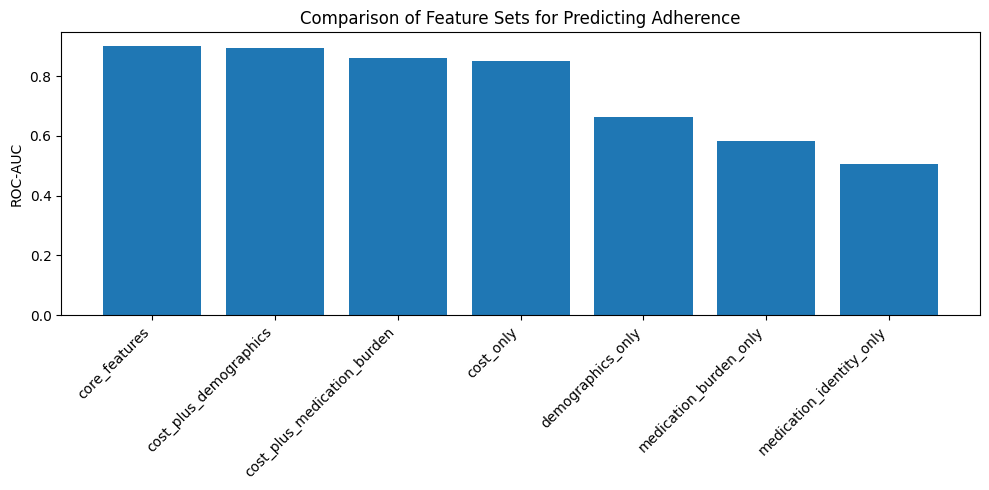

In [25]:
plt.figure(figsize=(10, 5))
plt.bar(results_df["feature_set"], results_df["roc_auc"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("ROC-AUC")
plt.title("Comparison of Feature Sets for Predicting Adherence")
plt.tight_layout()
plt.show()


## 8. Identify the best feature set

The code below selects the feature set with the highest ROC-AUC.


In [26]:
best_model = results_df.iloc[0]

print("Best feature set:", best_model["feature_set"])
print("Features:", best_model["features"])
print("ROC-AUC:", best_model["roc_auc"])
print("Accuracy:", best_model["accuracy"])
print("Precision:", best_model["precision"])
print("Recall:", best_model["recall"])


Best feature set: core_features
Features: copay_amount, patient_age, sex, days_supply, quantity_dispensed, refill_number, drug_name, pharmacy_name
ROC-AUC: 0.9020059582919563
Accuracy: 0.8333333333333334
Precision: 0.7011494252873564
Recall: 0.6421052631578947


## 9. Interpretation: Which features are most predictive of patient adherence?

Based on the model comparison results, the core_features feature set achieved the best overall performance, with a ROC-AUC of 0.902, accuracy of 0.833, precision of 0.701, and recall of 0.642. This indicates that a relatively small set of variables contains substantial predictive information about patient adherence.

The best-performing feature set included copay amount, patient age, sex, days supply, quantity dispensed, refill number, drug name, and pharmacy name. Several of these variables have a direct relationship to medication adherence. Copay amount may influence whether patients can consistently afford their medications, making cost an important predictor of refill behavior. Days supply, quantity dispensed, and refill number are closely tied to medication availability and prescription refill patterns, which are naturally associated with adherence outcomes.

Medication-related characteristics also appear to be important. Drug name may capture differences in side effects, dosing complexity, perceived effectiveness, or whether a medication is used for a chronic versus acute condition. Similarly, pharmacy name may reflect differences in pharmacy services, refill reminders, patient support programs, convenience, or access to medications.

Patient demographic factors such as age and sex contributed to the model, although they are likely less directly related to adherence than medication supply and cost variables. Their inclusion suggests that adherence patterns may vary across demographic groups, but these factors alone are unlikely to explain adherence behavior.

An important finding is that the core_features model outperformed more complex feature sets. This suggests that adding additional variables did not substantially improve predictive performance and may have introduced unnecessary complexity. Because the simpler model achieved a strong ROC-AUC while using fewer predictors, it may be preferable from both an interpretability and implementation standpoint.

Overall, the results suggest that patient adherence is primarily driven by a combination of medication cost, refill-related factors, medication characteristics, and pharmacy-related influences. The strong model performance and clinical plausibility of these predictors support their importance in understanding and predicting medication adherence.


## 10. Conclusion

This tutorial demonstrated the main functionality of the `pharma_adherence` package. The package was used to load and clean prescription data, save a processed dataset, visualize adherence-related variables, generate a patient adherence profile, and compare multiple feature sets for predicting adherence. The feature comparison shows how machine learning can be used not only for prediction, but also for understanding which types of variables may be most informative for medication adherence.
